# Electrostatic energy from atomic multipoles

This notebook loads periodic bulk structures and non-periodic clusters, builds
inputs for the electrostatic energy block, and evaluates the energy for random
multipoles.


In [51]:
import torch
from pathlib import Path
from scipy.constants import pi
from ase.io import read

from graph_longrange.kspace import compute_k_vectors_flat
from graph_longrange.energy import GTOElectrostaticEnergy
from graph_longrange.gto_utils import gto_basis_kspace_cutoff

torch.set_default_dtype(torch.float64)


In [52]:
example_dir = Path.cwd()
if not (example_dir / "bulk.xyz").exists():
    example_dir = Path("graph_longrange_refactor/examples")

bulk_structures = read(example_dir / "bulk.xyz", ":")
cluster_structures = read(example_dir / "clusters.xyz", ":")

print(f"Loaded {len(bulk_structures)} bulk configs")
print(f"Loaded {len(cluster_structures)} cluster configs")


Loaded 4 bulk configs
Loaded 4 cluster configs


This repo doesn't convert atoms into batched tensors, so we'll do this manually:

In [53]:
def atoms_list_to_batch(atoms_list):
    positions = []
    batch = []
    cells = []
    volumes = []
    pbcs = []

    for graph_i, atoms in enumerate(atoms_list):
        pos = torch.tensor(atoms.get_positions(), dtype=torch.get_default_dtype())
        positions.append(pos)
        batch.append(torch.full((pos.shape[0],), graph_i, dtype=torch.long))

        cell = torch.tensor(atoms.cell.array, dtype=torch.get_default_dtype())
        if torch.allclose(cell, torch.zeros_like(cell)):
            cell = torch.eye(3, dtype=cell.dtype)
        cells.append(cell)
        volumes.append(abs(torch.det(cell)))
        pbcs.append(torch.tensor(atoms.pbc, dtype=torch.bool))

    return (
        torch.cat(positions, dim=0),
        torch.cat(batch, dim=0),
        torch.stack(cells, dim=0),
        torch.stack(volumes, dim=0),
        torch.stack(pbcs, dim=0),
    )

In [54]:
# density_max_l is the multipole order. 0=charges, 1=charges+dipoles, etc...
# the realspace evalation is currently supported for only l<=1. 
density_max_l = 1

# this is sigma_n in the GTO basis, we generally use quite wide gaussians in ML models
density_smearing_width = 1.5

# use this function for a heuristic estimate of the k-space cutoff, 
# which is needed to determine the number of k-vectors to use in the reciprocal space sum.
kspace_cutoff = gto_basis_kspace_cutoff(
    sigmas=[density_smearing_width],
    max_l=density_max_l,
)

energy_block = GTOElectrostaticEnergy(
    density_max_l=density_max_l,
    density_smearing_width=density_smearing_width,
    kspace_cutoff=kspace_cutoff,
    include_self_interaction=True,
)

## Periodic bulk example

One needs to create a set of k-vectors based on the unit cell. For this, use `compute_k_vectors_flat`.

This function provides only a half sphere of k-vectors with $k_x>0$. This is because the functions are all real, so we only need to store half of the fourier series coefficients. 

as well as the `k_vectors`, the function returns
- `k_norm2`, squared norm of k_vectors
- `k_vector_batch`, a tensor like the `batch` describing which batch each k-vector belongs in
- `k0_mask` marks there the $\mathbf{k}=\mathbf{0}$ entries are. 


In [55]:
positions, batch, cell, volume, pbc = atoms_list_to_batch(bulk_structures)

r_cell = 2 * pi * torch.linalg.inv(cell).transpose(-1, -2)
k_vectors, k_norm2, k_vector_batch, k0_mask = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell,
    r_cell_vectors=r_cell,
)

# random multipoles which sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l+1)**2)
multipoles[:,0] -= multipoles[:,0].mean()

energy_bulk = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

energy_bulk


tensor([15.6373, 18.7276, 22.1115, 19.1163])

## Non-periodic cluster example

If all `pbc` flags are false, the class automatically uses the real-space
implementation and ignores the k-grid inputs.


In [56]:
positions, batch, cell, volume, pbc = atoms_list_to_batch(cluster_structures)

# charges don't have to sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l+1)**2)

# placeholders, ignored in real-space path
k_vectors = torch.zeros((1, 3), dtype=positions.dtype)
k_norm2 = torch.zeros((1,), dtype=positions.dtype)
k_vector_batch = torch.zeros((1,), dtype=torch.long)
k0_mask = torch.ones((1,), dtype=positions.dtype)

energy_cluster = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
    force_pbc_evaluator=False,
)

energy_cluster


tensor([1.2608, 2.2936, 9.2421, 6.2883])

## Mixed batches and forced periodic evaluation

If any graph in a batch has `pbc=True`, the periodic (k-space) path is used for
the full batch. You can also force the periodic path explicitly with
`force_pbc_evaluator=True`.


### Dipole correction for a slab (z axis only)

Here we set `pbc=TTF` for a single config and compare energies. TTF enables the dipole correction.

> 
> NOTE:
>
> slabs in this repo must have the nonperiodic direction equal to the third cell vector (~ z diection)
>


In [57]:
# make a slab
slab_atoms = bulk_structures[0].copy()
cell = slab_atoms.get_cell()
cell[2,2] = 60.0
slab_atoms.set_cell(cell)

# get k vectors for this cell shape
positions, batch, cell, volume, pbc = atoms_list_to_batch([slab_atoms])
r_cell = 2 * pi * torch.linalg.inv(cell).transpose(-1, -2)
k_vectors, k_norm2, k_vector_batch, k0_mask = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell,
    r_cell_vectors=r_cell,
)

# set some multipoles which sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l+1)**2)
multipoles[:,0] -= multipoles[:,0].mean()

# set pbc to TTT and get energy:
slab_atoms.set_pbc([True, True, True])
positions, batch, cell, volume, pbc = atoms_list_to_batch([slab_atoms])

energy_periodic = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

# set pbc to TTF and get energy:
slab_atoms.set_pbc([True, True, False])
positions, batch, cell, volume, pbc = atoms_list_to_batch([slab_atoms])

energy_slab = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)
 
energy_periodic, energy_slab

(tensor([22.2197]), tensor([34.3109]))

the difference can be very large because we are using random multipoles and hence the dipole may be large.

## Convergence rate of energy with and without the dipole correction

The cell below computes the energy for the same config above as a function of z direction cell length, with and without the dipole correction.


get a sense for the number of k-vectors:
 box length (Ang) 	| number of k-vectors 
---------------------------------------------
	30.0 		| 	293  
	43.4 		| 	421  
	62.9 		| 	623  
	91.0 		| 	899  
	131.8 		| 	1299  
	190.8 		| 	1873  
	276.3 		| 	2710  
	400.0 		| 	3922  


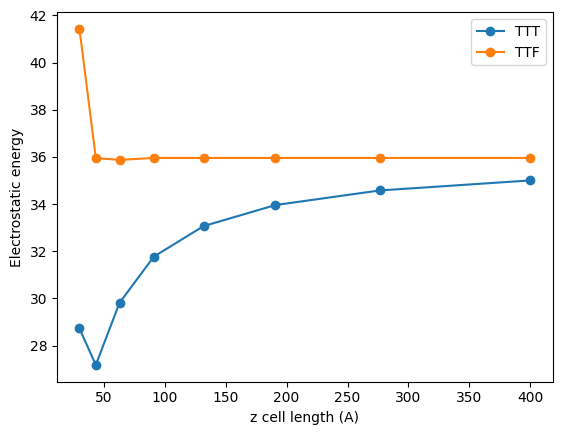

In [58]:
# batch evaluation across varying z lengths
import numpy as np
import matplotlib.pyplot as plt

lengths = np.geomspace(30.0, 400.0, 8)
slabs_ttt = []
slabs_ttf = []

for length in lengths:
    atoms = bulk_structures[0].copy()
    cell = atoms.get_cell()
    cell[2, 2] = float(length)
    atoms.set_cell(cell)

    atoms_ttt = atoms.copy()
    atoms_ttt.set_pbc([True, True, True])
    slabs_ttt.append(atoms_ttt)

    atoms_ttf = atoms.copy()
    atoms_ttf.set_pbc([True, True, False])
    slabs_ttf.append(atoms_ttf)

# TTT batch
positions_ttt, batch_ttt, cell_ttt, volume_ttt, pbc_ttt = atoms_list_to_batch(slabs_ttt)
r_cell_ttt = 2 * pi * torch.linalg.inv(cell_ttt).transpose(-1, -2)
k_vectors_ttt, k_norm2_ttt, k_vector_batch_ttt, k0_mask_ttt = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell_ttt,
    r_cell_vectors=r_cell_ttt,
)
multipoles = 0.25 * torch.randn(192, (density_max_l + 1) ** 2)
multipoles[:, 0] -= multipoles[:, 0].mean()
multipoles = multipoles.repeat(lengths.shape[0], 1)

energies_ttt = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_ttt,
    batch=batch_ttt,
    volume=volume_ttt,
    pbc=pbc_ttt,
)

# TTF batch
positions_ttf, batch_ttf, cell_ttf, volume_ttf, pbc_ttf = atoms_list_to_batch(slabs_ttf)
energies_ttf = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_ttf,
    batch=batch_ttf,
    volume=volume_ttf,
    pbc=pbc_ttf,
)

plt.figure()
plt.plot(lengths, energies_ttt.detach().cpu().numpy(), "-o", label="TTT")
plt.plot(lengths, energies_ttf.detach().cpu().numpy(), "-o", label="TTF")
plt.xlabel("z cell length (A)")
plt.ylabel("Electrostatic energy")
plt.legend()

print('\nget a sense for the number of k-vectors:')
num_k_vectors_per_graph = torch.bincount(k_vector_batch_ttt)
print(' box length (Ang) \t| number of k-vectors ')
print('---------------------------------------------')
for length, num_k in zip(lengths, num_k_vectors_per_graph):
    print(f'\t{length:.1f} \t\t| \t{num_k}  ')

## Periodic evaluation for a cluster in a box

The keyword `force_pbc_evaluator=True` can be used to  evaluate a cluster config (`pbc=FFF`) with the periodic code. You need to set a unit cell which is comfortably bigger than the config, and for highly charged configs, this can still uncur some errors. 

When doing a periodic calculation of a cluster, monopole and dipole corrections are added to the energy. 

The energy you get from doing a periodic calcuation of a `pbc=FFF`, via the `force_pbc_evaluator` will be close to, but not identical to the energy from the actual realspace evaluator:

In [59]:
cluster = cluster_structures[0].copy()
cluster.set_cell([30.0, 30.0, 30.0])
cluster.set_pbc([False, False, False])

positions, batch, cell, volume, pbc = atoms_list_to_batch([cluster])
r_cell = 2 * pi * torch.linalg.inv(cell).transpose(-1, -2)
k_vectors, k_norm2, k_vector_batch, k0_mask = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell,
    r_cell_vectors=r_cell,
)

# multipoles which don't sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l + 1) ** 2)
print('total charge:', multipoles[:, 0].sum().item())

# realspace evaluation
energy_realspace_evaluator = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

# pbc evaluation with FFF, which adds monopole/dipole corrections
energy_periodic_evaluator = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
    force_pbc_evaluator=True,
)

# also compute the energy with TTT to show the size of the error
cluster.set_pbc([True, True, True])
positions, batch, cell, volume, pbc = atoms_list_to_batch([cluster])
energy_TTT = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

print('Energy real-space:', energy_realspace_evaluator.item())
print('Energy periodic:', energy_periodic_evaluator.item())
print('Energy TTT:', energy_TTT.item())

total charge: 0.9111668564829155
Energy real-space: 3.703495130320614
Energy periodic: 3.7073607661502646
Energy TTT: 3.1366424125080696


## Convergence of periodic energy of clusters

total charge: -0.5445924767002268

doing clusters in huge boxes rapidly gets expensive:
 box length (Ang) 	| number of k-vectors 
---------------------------------------------
	15.0 		| 	183  
	19.7 		| 	400  
	25.8 		| 	920  
	33.8 		| 	2034  
	44.4 		| 	4586  
	58.2 		| 	10432  
	76.3 		| 	23629  
	100.0 		| 	53072  


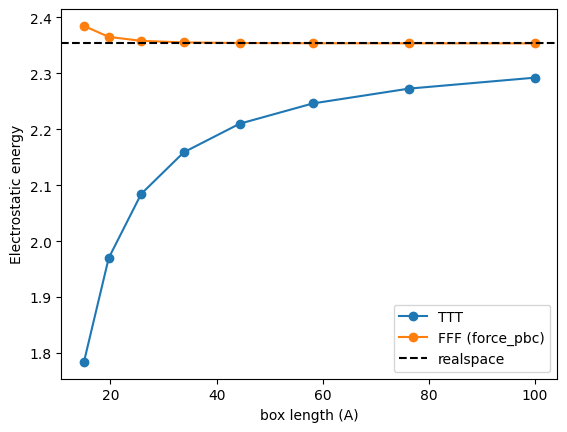

In [60]:
# convergence with cell size for a cluster in a box
import numpy as np
import matplotlib.pyplot as plt

lengths = np.geomspace(15.0, 100.0, 8)

cluster_base = cluster_structures[0].copy()
cluster_base.set_pbc([False, False, False])

base_positions, _, _, _, _ = atoms_list_to_batch([cluster_base])
multipoles_base = 0.25 * torch.randn(base_positions.shape[0], (density_max_l + 1) ** 2)
print('total charge:', multipoles_base[:, 0].sum().item())

# realspace energy (computed once)
cluster_real = cluster_base.copy()
cluster_real.set_cell([30.0, 30.0, 30.0])
positions_rs, batch_rs, cell_rs, volume_rs, pbc_rs = atoms_list_to_batch([cluster_real])
r_cell_rs = 2 * pi * torch.linalg.inv(cell_rs).transpose(-1, -2)
k_vectors_rs, k_norm2_rs, k_vector_batch_rs, k0_mask_rs = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell_rs,
    r_cell_vectors=r_cell_rs,
)
energy_realspace = energy_block(
    k_vectors=k_vectors_rs,
    k_norm2=k_norm2_rs,
    k_vector_batch=k_vector_batch_rs,
    k0_mask=k0_mask_rs,
    source_feats=multipoles_base,
    node_positions=positions_rs,
    batch=batch_rs,
    volume=volume_rs,
    pbc=pbc_rs,
)

clusters_ttt = []
clusters_fff = []
for length in lengths:
    atoms = cluster_base.copy()
    atoms.set_cell([float(length), float(length), float(length)])

    atoms_ttt = atoms.copy()
    atoms_ttt.set_pbc([True, True, True])
    clusters_ttt.append(atoms_ttt)

    atoms_fff = atoms.copy()
    atoms_fff.set_pbc([False, False, False])
    clusters_fff.append(atoms_fff)

# TTT batch
positions_ttt, batch_ttt, cell_ttt, volume_ttt, pbc_ttt = atoms_list_to_batch(clusters_ttt)
r_cell_ttt = 2 * pi * torch.linalg.inv(cell_ttt).transpose(-1, -2)
k_vectors_ttt, k_norm2_ttt, k_vector_batch_ttt, k0_mask_ttt = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell_ttt,
    r_cell_vectors=r_cell_ttt,
)
multipoles = multipoles_base.repeat(len(lengths), 1)

energies_ttt = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_ttt,
    batch=batch_ttt,
    volume=volume_ttt,
    pbc=pbc_ttt,
)

# FFF batch (forced periodic evaluator)
positions_fff, batch_fff, cell_fff, volume_fff, pbc_fff = atoms_list_to_batch(clusters_fff)
energies_fff = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_fff,
    batch=batch_fff,
    volume=volume_fff,
    pbc=pbc_fff,
    force_pbc_evaluator=True,
)

plt.figure()
plt.plot(lengths, energies_ttt.detach().cpu().numpy(), "-o", label="TTT")
plt.plot(lengths, energies_fff.detach().cpu().numpy(), "-o", label="FFF (force_pbc)")
plt.axhline(energy_realspace.item(), linestyle="--", color="k", label="realspace")
plt.xlabel("box length (A)")
plt.ylabel("Electrostatic energy")
plt.legend()

print('\ndoing clusters in huge boxes rapidly gets expensive:')
num_k_vectors_per_graph = torch.bincount(k_vector_batch_ttt)
print(' box length (Ang) \t| number of k-vectors ')
print('---------------------------------------------')
for length, num_k in zip(lengths, num_k_vectors_per_graph):
    print(f'\t{length:.1f} \t\t| \t{num_k}  ')

## Mixed PBC batches

If your batch has a mixture of pbc, the following rules apply:
- if all configs are FFF, use realspace evaluator
- otherwise, use pbc evaluator and apply corrections above on a per-config basis. 